In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# La batalla del cifrado: ¿Lineal o polinomial? Descubre el método más rápido para proteger tus datos

Integrantes:
Diego Abad,
Benjamín Carmona,
Gonzalo Olhabe y
Juan Pablo Sanchez

# Instrucciones

1. Lea detenidamente el enunciado y las preguntas.
2. Escriba sus desarrollos a continuación de la celda que dice “Desarrollo”.
3. Se sugiere usar una celda de texto con el número de la pregunta, una o más celdas de código para el desarrollo y luego una celda de texto para escribir la respuesta.

# Enunciado

La empresa de Ciberseguridad Seguri-net está analizando dos métodos de encriptación para archivos desde $10$ MB hasta $80$ MB. En el primer método, por cada incremento de $2$ MB en el tamaño del archivo, el tiempo de encriptación se incrementa de manera constante en $0,8$ segundos, tal como muestra la tabla (Método A). Mientras que el segundo método (Método B) tiene un tiempo de encriptación, también en segundos, que varía de acuerdo a un modelo cuadrático.

#### Método A:
<center>

| Tamaño del archivo (MB) | Tiempo de encriptación (segundos) | 
|-------------------------|---------------------|
|$$10$$                  |$$7,4$$               |
|$$22$$                  |$$12,2$$              |
|$$40$$                  |$$19,4$$              |
|$$53$$                  |$$24,6$$              |
|$$76$$                  |$$33,8$$              |

</center>

#### Método B:


$$g(x)=0,01x^2-0,25x+10$$

Con ayuda de Python resuelve las siguientes preguntas, considera un decimal para responder:

1. ¿Qué tipo de función permite calcular el tiempo de encriptación si se usa el método A? Justifica tu respuesta. Además, determina la forma algebraica de la función que modela el tiempo de encriptación en función del tamaño del archivo en el método A. 
2. Calcula el tiempo de encriptación para ambos métodos cuando el tamaño del archivo es $27$ MB. ¿Cuál método empleó menos tiempo?
3. ¿Para qué tamaño(s) de archivo el tiempo de encriptación es el mismo en ambos métodos? ¿Cuál es el tiempo de encriptación?
4. En términos de tiempo, ¿para qué tamaño de archivos es más conveniente el método B?

# Desarrollo

### 1.Debido al incremento de forma constante (0,8 cada 2 mb o 0,4 x mb) se puede inferir que el metodo A pertence a un tipo de funcion lineal.

In [2]:
x = np.array([10, 22, 40, 53, 76])
y = np.array([7.4, 12.2, 19.4, 24.6,33.8])
#Si la función es de grado 1
pendiente, intercepto = np.polyfit(x, y, 1)
print(f"el valor de la pendiente es de {pendiente:.2f} y el valor del intercepto es de {intercepto:.2f}")
print("por ende la forma algebraica de la función del metodo A es:")

def f(x):
    return 0.4*x + 3.4

def g(x):
    return 0.01*x**2 - 0.25*x + 10


el valor de la pendiente es de 0.40 y el valor del intercepto es de 3.40
por ende la forma algebraica de la función del metodo A es:


#### Método A:


$$f(x)=0,4x+3,4$$

### 2.) Con un archivo de 27mb los metodos obtienen los siguientes resultados:

In [ ]:
#metodo a
resultadoA = f(27)
#metodo b
resultadoB = g(27)

print(f"El Método A se demora {resultadoA:.2f} segundos y el método B se demora {resultadoB:.2f}")

if resultadoB > resultadoA:
    print("El Método A es mas veloz que el Método B")
elif resultadoA > resultadoB:
    print ("El Método B es más veloz que el Método A")    

El Método A se demora 14.20 segundos y el método B se demora 10.54
El Método B es mas veloz que el Metodo A


### 3.) Intersecciones (los tamaños de los archivos donde ambos metodos se demoran lo mismo):

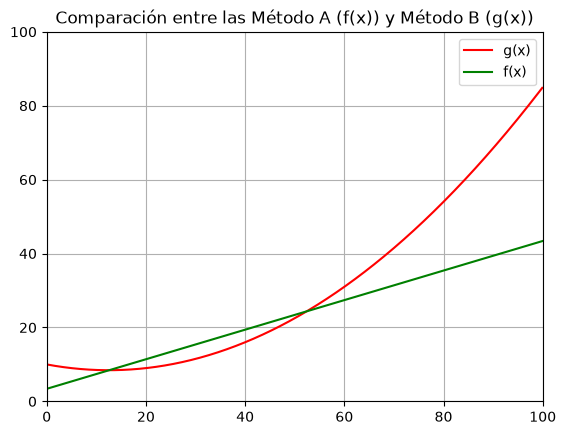

In [11]:
x = np.arange(0, 100, 0.1)
plt.plot(x, g(x), color = 'r', label = 'g(x)')
plt.plot(x, f(x), color = 'g', label = 'f(x)')
plt.ylim(0, 100)
plt.xlim(0, 100)

plt.title('Comparación entre las Método A (f(x)) y Método B (g(x))')

plt.grid(True)
plt.legend()
plt.show()

In [8]:
def inter(x):
  return g(x)-f(x)

x = np.linspace(0, 100, 2)

#np.around() permite redondear los valores a 2 decimales y elimina los restantes
solucion = np.around(fsolve(inter, x), decimals = 2)

#np.unique() permite eliminar las soluciones repetidas
interseccion = np.unique(solucion)

print(f'Los puntos de intersección de las funciones están en x = {interseccion}')

resultado = g(interseccion)

print (f"Los resultados en terminos de tiempo son {resultado[0]:.2f} segundos para un archivo con {interseccion[0]:.2f} mbs de tamaño ")
print (f"y los resultados en terminos de tiempo son {resultado[1]:.2f} segundos para un archivo con {interseccion[1]:.2f} mbs de tamaño ")


Los puntos de intersección de las funciones están en x = [12.59 52.41]
Los resultados en terminos de tiempo son 8.44 segundos para un archivo con 12.59 mbs de tamaño 
y los resultados en terminos de tiempo son 24.37 segundos para un archivo con 52.41 mbs de tamaño 


### 4.) Analísis de grafico y resultados.

Es mas conveniente usar el método A con archivos menores a 12.59 mbs y archivos mayores a 52.41 mbs.

El metodo B es mas conveniente para archivos dentro del rango de los 12.59 mbs y los 52.41 mbs

Ambos metodos son iguales en 12.59 mbs y 52.41 mbs